<a href="https://colab.research.google.com/github/teemus28/Machine-Learning/blob/main/FE_Pipeline_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [ ]:
steps = [("Standard Scaling",StandardScaler()),('Classifier',LogisticRegression())]

In [ ]:
pipe = Pipeline(steps)   #in jupiter notebook we use 'set_config' to display pipeline

In [ ]:
pipe

Pipeline(steps=[('Standard Scaling', StandardScaler()),
                ('Classifier', LogisticRegression())])

In [ ]:
from sklearn.datasets import make_classification
x,y=make_classification()

In [ ]:
x.shape

(100, 20)

In [ ]:
y.shape

(100,)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [ ]:
x_train.shape

(80, 20)

In [ ]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('Standard Scaling', StandardScaler()),
                ('Classifier', LogisticRegression())])

In [ ]:
y_pred = pipe.predict(x_test)

In [ ]:
y_pred

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0])

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
steps= [("Standard Scaling",StandardScaler()),("SimpleImputer",SimpleImputer()),('OneHotEncoder',OneHotEncoder()),('Classifier',LogisticRegression())]

In [ ]:
pipe_2=Pipeline(steps)

In [ ]:
pipe_2

Pipeline(steps=[('Standard Scaling', StandardScaler()),
                ('SimpleImputer', SimpleImputer()),
                ('OneHotEncoder', OneHotEncoder()),
                ('Classifier', LogisticRegression())])

**Pipeline using transformers**

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression

In [ ]:
numeric_data = Pipeline(
    steps = [('Impute_by_mean',SimpleImputer(strategy='mean')),('Standard Scaler',StandardScaler())]
)

In [ ]:
numeric_data

Pipeline(steps=[('Impute_by_mean', SimpleImputer()),
                ('Standard Scaler', StandardScaler())])

In [ ]:
categorical_data = Pipeline(
    steps = [('Impute_by_const',SimpleImputer(fill_value="missing",strategy='constant')),("encode_data",OneHotEncoder())]
)

In [ ]:
categorical_data

Pipeline(steps=[('Impute_by_const',
                 SimpleImputer(fill_value='missing', strategy='constant')),
                ('encode_data', OneHotEncoder())])

In [ ]:
#Now combine both numerical and categorical techniques
from sklearn.compose import ColumnTransformer
txn = ColumnTransformer(
    [('Categorical',categorical_data,['gender','city']),
     ("Numerical",numeric_data,['age','height'])]
)


In [ ]:
txn

ColumnTransformer(transformers=[('Categorical',
                                 Pipeline(steps=[('Impute_by_const',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('encode_data',
                                                  OneHotEncoder())]),
                                 ['gender', 'city']),
                                ('Numerical',
                                 Pipeline(steps=[('Impute_by_mean',
                                                  SimpleImputer()),
                                                 ('Standard Scaler',
                                                  StandardScaler())]),
                                 ['age', 'height'])])

In [ ]:
#now combining all
from sklearn.pipeline import make_pipeline
make_pipeline(txn,LogisticRegression())

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('Categorical',
                                                  Pipeline(steps=[('Impute_by_const',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encode_data',
                                                                   OneHotEncoder())]),
                                                  ['gender', 'city']),
                                                 ('Numerical',
                                                  Pipeline(steps=[('Impute_by_mean',
                                                                   SimpleImputer()),
                                                                  ('Standard '
                                                                   'Scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'height'])])),
                ('logisticregression', LogisticRegression())])

More complex pipeline

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/tested.csv")

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [ ]:
# drop - 	PassengerId,Name,Ticket,	Cabin

In [ ]:
df.drop(columns = ['PassengerId','Name','Ticket','Cabin'],inplace=True)

In [ ]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,34.5,0,0,7.8292,Q
1,1,3,female,47.0,1,0,7.0000,S
2,0,2,male,62.0,0,0,9.6875,Q
3,0,3,male,27.0,0,0,8.6625,S
4,1,3,female,22.0,1,1,12.2875,S
...,...,...,...,...,...,...,...,...
413,0,3,male,NaN,0,0,8.0500,S
414,1,1,female,39.0,0,0,108.9000,C
415,0,3,male,38.5,0,0,7.2500,S
416,0,3,male,NaN,0,0,8.0500,S


In [ ]:
df_x = df.iloc[:,1:]

In [ ]:
df_x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


In [ ]:
df_y = df.iloc[:,0]

In [ ]:
df_y = pd.DataFrame(df_y)
df_y.head()

,Survived
0,0
1,1
2,0
3,0
4,1


In [ ]:
df_x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


In [ ]:
df_x['Embarked'].unique()  #Sex and Embarked - OHE

array(['Q', 'S', 'C'], dtype=object)

In [ ]:
df_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    object 
 2   Age       332 non-null    float64
 3   SibSp     418 non-null    int64  
 4   Parch     418 non-null    int64  
 5   Fare      417 non-null    float64
 6   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 23.0+ KB


In [ ]:
#age and fare has null values - SI

<Axes: ylabel='Age'>

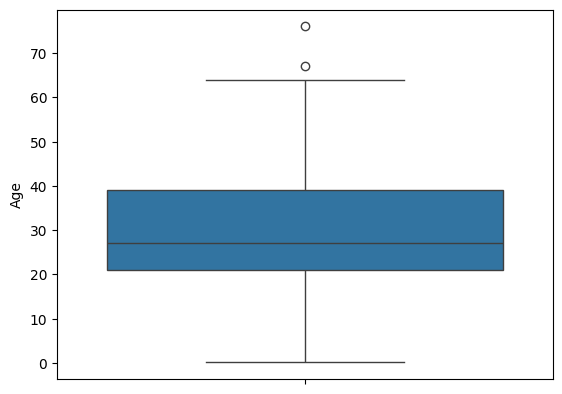

In [ ]:
import seaborn as sbn
sbn.boxplot(df_x['Age'])

<Axes: ylabel='Fare'>

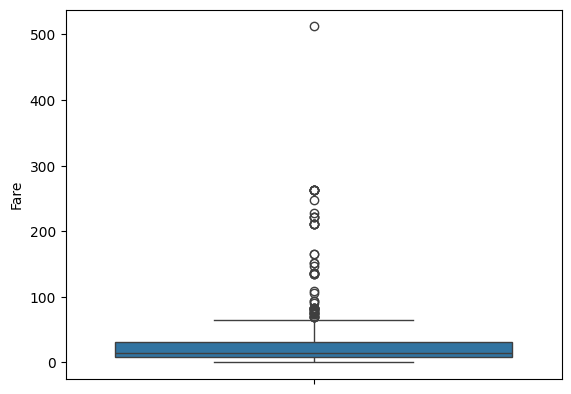

In [ ]:
sbn.boxplot(df_x['Fare'])

In [ ]:
#Fare has many outliers , so we use MinMaxScaler

In [ ]:
#creating 3 vertical txn/s for SI,OHE,MinMaxScaler

In [ ]:
#age and fare has null values - SI

In [ ]:
age = ('imputer_age',SimpleImputer(strategy='mean'),[2])  #2nd col
fare = ('imputer_fare',SimpleImputer(strategy='most_frequent'),[5])
txn1 = [age,fare]

In [ ]:
imputer_txn = ColumnTransformer(txn1 ,  remainder='passthrough')  #rest col will flow out

In [ ]:
imputer_txn

ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer_age', SimpleImputer(), [2]),
                                ('imputer_fare',
                                 SimpleImputer(strategy='most_frequent'),
                                 [5])])

In [ ]:
 #Sex and Embarked - OHE

In [ ]:
sex = ("Gender_embarked_OHE",OneHotEncoder(sparse_output=False, handle_unknown='ignore'),[1])
embarked = ("embarked_OHE",OneHotEncoder(sparse_output=False, handle_unknown='ignore'),[6])
txn2=[sex,embarked]


In [ ]:
ohe_txn = ColumnTransformer(txn2,remainder='passthrough')

In [ ]:
ohe_txn

ColumnTransformer(remainder='passthrough',
                  transformers=[('Gender_embarked_OHE',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 [1]),
                                ('embarked_OHE',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 [6])])

In [ ]:
txn3=[("Scaling",MinMaxScaler(),slice(0,10))]  #all cols

In [ ]:
scale_txn = ColumnTransformer(txn3 )

In [ ]:
scale_txn

ColumnTransformer(transformers=[('Scaling', MinMaxScaler(),
                                 slice(0, 10, None))])

In [ ]:
#join 3 txn/s

In [ ]:
model = LogisticRegression()

In [ ]:
pipe_main = make_pipeline(imputer_txn,ohe_txn,scale_txn,model)

In [ ]:
pipe_main

Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imputer_age',
                                                  SimpleImputer(), [2]),
                                                 ('imputer_fare',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [5])])),
                ('columntransformer-2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Gender_embarked_OHE',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1]),
                                                 ('embarked_OHE',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [6])])),
                ('columntransformer-3',
                 ColumnTransformer(transformers=[('Scaling', MinMaxScaler(),
                                                  slice(0, 10, None))])),
                ('logisticregression', LogisticRegression())])

In [ ]:
df_x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


In [ ]:
df_y.head()

,Survived
0,0
1,1
2,0
3,0
4,1


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(df_x,df_y,test_size=0.2)

In [ ]:
X_train.shape

(334, 7)

In [ ]:
df_x.shape

(418, 7)

In [ ]:
pipe_main.fit(X_train,Y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imputer_age',
                                                  SimpleImputer(), [2]),
                                                 ('imputer_fare',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [5])])),
                ('columntransformer-2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Gender_embarked_OHE',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1]),
                                                 ('embarked_OHE',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [6])])),
                ('columntransformer-3',
                 ColumnTransformer(transformers=[('Scaling', MinMaxScaler(),
                                                  slice(0, 10, None))])),
                ('logisticregression', LogisticRegression())])

In [ ]:
y_predict = pipe_main.predict(X_test)

In [ ]:
y_predict

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
y_test

array([0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_predict)

0.6190476190476191

In [ ]:
#saving our pipeline

In [ ]:
import pickle
pickle.dump(pipe_main, open('pipe_model.pkl', 'wb'))

Opening saved pipeline

In [ ]:
pipe_model = pickle.load(open('/content/pipe_model.pkl', 'rb'))

In [ ]:
pipe_model

Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imputer_age',
                                                  SimpleImputer(), [2]),
                                                 ('imputer_fare',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [5])])),
                ('columntransformer-2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Gender_embarked_OHE',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1]),
                                                 ('embarked_OHE',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [6])])),
                ('columntransformer-3',
                 ColumnTransformer(transformers=[('Scaling', MinMaxScaler(),
                                                  slice(0, 10, None))])),
                ('logisticregression', LogisticRegression())])